# Практическая работа №3
## Генерация табличных данных

**Дисциплина:** Математика в программировании, часть 2/2.

**Датасет:** UCI Heart Disease из практических работ №1 и №2.

**Задача:** получить синтетические табличные данные, на которых можно обучить
дискриминативную модель для бинарной классификации наличия сердечно-сосудистого
заболевания.

Основная проверка качества синтетики в этой работе - **TSTR**:
`Train on Synthetic, Test on Real`. Модель обучается на синтетических данных,
а тестируется на реальной test-части исходного набора.

## 1. Логика работы

В первой практической работе исходные данные были очищены, стандартизированы и
закодированы. Во второй работе на этих данных сравнивались дискриминативные
модели. В третьей работе используется тот же датасет и тот же тип задачи, но
вместо обучения классификатора только на реальном train-наборе сначала
генерируются синтетические train-наборы.

Реализуются три подхода к генерации:

- `GaussianMixture` - классическая ненейронная генеративная модель;
- `MLPRegressor` как denoising-autoencoder - нейронная генеративная модель;
- экспертный генератор правил - генерация клинически согласованных строк в
  исходном признаковом пространстве с последующей предобработкой из практики №1.

Для каждого генератора проверяются два объёма синтетики: размер исходного
train-набора (`x1`) и увеличенный размер (`x3`).

In [2]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "labs" / "lab1").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

LAB1_DIR = PROJECT_ROOT / "labs" / "lab1"
LAB2_DIR = PROJECT_ROOT / "labs" / "lab2"
LAB3_DIR = PROJECT_ROOT / "labs" / "lab3"
DATA_DIR = LAB1_DIR / "heart+disease"
PREPROCESSED_PATH = LAB1_DIR / "heart_disease_preprocessed.csv"
LAB2_METRICS_PATH = LAB2_DIR / "lab2_heart_disease_model_metrics.csv"

os.environ["MPLCONFIGDIR"] = str(PROJECT_ROOT / ".cache" / "mathprog_lab3" / "matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
RAW_GRADIENT_BOOSTING_F1_BASELINE = 0.721311
BEST_LAB2_PROCESSED_F1 = 0.876923
TARGET_LABELS = ["нет болезни", "есть болезнь"]

## 2. Загрузка данных и восстановление предобработки

Основной train/test split строится по файлу `heart_disease_preprocessed.csv`,
полученному в первой практической работе. Для экспертного генератора дополнительно
восстанавливается исходное очищенное признаковое пространство: возраст, давление,
холестерин, тип боли в груди, ЭКГ и другие медицинские признаки.

In [3]:
columns = [
    "age",       # возраст
    "sex",       # пол: 1 - male, 0 - female
    "cp",        # тип боли в груди
    "trestbps",  # давление в покое
    "chol",      # холестерин
    "fbs",       # сахар натощак > 120 mg/dl
    "restecg",   # ЭКГ в покое
    "thalach",   # максимальная ЧСС
    "exang",     # стенокардия при нагрузке
    "oldpeak",   # депрессия ST
    "slope",     # наклон сегмента ST
    "ca",        # число крупных сосудов
    "thal",      # результат thal-теста
    "num",       # исходная целевая переменная
]

source_files = {
    "Cleveland": "processed.cleveland.data",
    "Hungarian": "processed.hungarian.data",
    "Switzerland": "processed.switzerland.data",
    "Long Beach VA": "processed.va.data",
}

frames = []
for source, filename in source_files.items():
    part = pd.read_csv(
        DATA_DIR / filename,
        header=None,
        names=columns,
        na_values="?",
    )
    part["source"] = source
    frames.append(part)

raw = pd.concat(frames, ignore_index=True)
raw_clean = raw.drop_duplicates().reset_index(drop=True)
raw_clean["target"] = (raw_clean["num"] > 0).astype(int)

raw_clean.loc[raw_clean["chol"] == 0, "chol"] = np.nan
raw_clean.loc[raw_clean["trestbps"] == 0, "trestbps"] = np.nan

initial_features = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal"
]

missing_rate = raw_clean[initial_features].isna().mean()
high_missing_cols = missing_rate[missing_rate > 0.60].index.tolist()
model_features = [col for col in initial_features if col not in high_missing_cols]
cols_with_missing = [col for col in model_features if raw_clean[col].isna().any()]

for col in cols_with_missing:
    raw_clean[f"{col}_was_missing"] = raw_clean[col].isna().astype(int)

numeric_raw_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_raw_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
indicator_features = [f"{col}_was_missing" for col in cols_with_missing]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_raw_features),
        ("cat", categorical_transformer, categorical_raw_features),
        ("missing_flag", "passthrough", indicator_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

preprocessor.set_output(transform="pandas")
rebuilt_preprocessed = preprocessor.fit_transform(raw_clean[model_features + indicator_features])

prepared = pd.read_csv(PREPROCESSED_PATH)
meta_cols = ["target", "severity_num", "source"]
feature_cols = [col for col in prepared.columns if col not in meta_cols]

X = prepared[feature_cols].astype(float)
y = prepared["target"].astype(int)

rebuilt_common_cols = [col for col in rebuilt_preprocessed.columns if col in feature_cols]
max_rebuild_diff = (
    rebuilt_preprocessed[rebuilt_common_cols].reset_index(drop=True)
    .sub(X[rebuilt_common_cols].reset_index(drop=True))
    .abs()
    .to_numpy()
    .max()
)

train_idx, test_idx = train_test_split(
    prepared.index.to_numpy(),
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train = X.loc[train_idx].reset_index(drop=True)
y_train = y.loc[train_idx].reset_index(drop=True)
X_test = X.loc[test_idx].reset_index(drop=True)
y_test = y.loc[test_idx].reset_index(drop=True)
raw_train = raw_clean.loc[train_idx].reset_index(drop=True)

data_summary = pd.DataFrame(
    [
        {
            "Набор": "Полный processed-набор",
            "Строк": len(prepared),
            "Признаков": X.shape[1],
            "Класс 0": int((y == 0).sum()),
            "Класс 1": int((y == 1).sum()),
        },
        {
            "Набор": "Real train",
            "Строк": len(X_train),
            "Признаков": X_train.shape[1],
            "Класс 0": int((y_train == 0).sum()),
            "Класс 1": int((y_train == 1).sum()),
        },
        {
            "Набор": "Real test",
            "Строк": len(X_test),
            "Признаков": X_test.shape[1],
            "Класс 0": int((y_test == 0).sum()),
            "Класс 1": int((y_test == 1).sum()),
        },
    ]
)

display(data_summary)
print("Удалённый из-за пропусков признак:", high_missing_cols)
print("Признаки с индикаторами пропусков:", cols_with_missing)
print(f"Максимальное отличие восстановленной предобработки от файла из 1 лабы: {max_rebuild_diff:.10f}")

,Набор,Строк,Признаков,Класс 0,Класс 1
0,Полный processed-набор,918,33,410,508
1,Real train,688,33,307,381
2,Real test,230,33,103,127


Удалённый из-за пропусков признак: ['ca']
Признаки с индикаторами пропусков: ['trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'thal']
Максимальное отличие восстановленной предобработки от файла из 1 лабы: 0.0000000000


In [4]:
lab2_metrics = pd.read_csv(LAB2_METRICS_PATH)
display(lab2_metrics.sort_values(["Dataset", "F1"], ascending=[True, False]).round(4))

print(
    "Порог из комментария преподавателя: F1 Gradient Boosting на сырых данных =",
    RAW_GRADIENT_BOOSTING_F1_BASELINE,
)
print(
    "Лучший ориентир из практики №2 на processed-данных: F1 Weighted Voting Ensemble =",
    BEST_LAB2_PROCESSED_F1,
)

,Dataset,Model,Rows,Train rows,Test rows,Accuracy,Precision,Recall,F1,ROC-AUC
5,Предобработанные данные,Voting Ensemble,918,688,230,0.8565,0.8507,0.8976,0.8736,0.9134
6,Предобработанные данные,Weighted Voting Ensemble,918,688,230,0.8522,0.8550,0.8819,0.8682,0.9135
7,Предобработанные данные,Logistic Regression,918,688,230,0.8478,0.8538,0.8740,0.8638,0.9179
8,Предобработанные данные,Random Forest,918,688,230,0.8435,0.8473,0.8740,0.8605,0.9067
9,Предобработанные данные,Gradient Boosting,918,688,230,0.8304,0.8188,0.8898,0.8528,0.9028
0,Сырые данные,Logistic Regression,299,224,75,0.8267,0.8438,0.7714,0.8060,0.9321
1,Сырые данные,Weighted Voting Ensemble,299,224,75,0.8133,0.8621,0.7143,0.7812,0.9286
2,Сырые данные,Random Forest,299,224,75,0.8000,0.8333,0.7143,0.7692,0.9143
3,Сырые данные,Voting Ensemble,299,224,75,0.8000,0.8571,0.6857,0.7619,0.9271
4,Сырые данные,Gradient Boosting,299,224,75,0.7733,0.8462,0.6286,0.7213,0.8557


Порог из комментария преподавателя: F1 Gradient Boosting на сырых данных = 0.721311
Лучший ориентир из практики №2 на processed-данных: F1 Weighted Voting Ensemble = 0.876923


## 3. Общие функции для генераторов

Генераторы обучаются только на `real train`. Реальная test-часть не используется
при генерации и нужна только для TSTR-проверки.

После генерации выполняется постобработка:

- стандартизированные числовые признаки ограничиваются наблюдаемыми квантилями;
- one-hot группы приводятся к ровно одному активному значению;
- бинарные индикаторы пропусков приводятся к `0/1`;
- целевой класс сохраняется отдельно и не смешивается с признаками.

In [5]:
processed_numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
onehot_groups = {
    "sex": ["sex_0.0", "sex_1.0"],
    "cp": ["cp_1.0", "cp_2.0", "cp_3.0", "cp_4.0"],
    "fbs": ["fbs_0.0", "fbs_1.0"],
    "restecg": ["restecg_0.0", "restecg_1.0", "restecg_2.0"],
    "exang": ["exang_0.0", "exang_1.0"],
    "slope": ["slope_1.0", "slope_2.0", "slope_3.0"],
    "thal": ["thal_3.0", "thal_6.0", "thal_7.0"],
}
onehot_cols = [col for cols in onehot_groups.values() for col in cols]
missing_indicator_cols = [col for col in feature_cols if col.endswith("_was_missing")]
binary_cols = onehot_cols + missing_indicator_cols

numeric_clip_bounds = X_train[processed_numeric_cols].quantile([0.005, 0.995])


def allocate_class_counts(y_reference, n_rows):
    proportions = y_reference.value_counts(normalize=True).sort_index()
    raw_counts = proportions * n_rows
    counts = np.floor(raw_counts).astype(int)
    remainder = int(n_rows - counts.sum())

    if remainder > 0:
        fractional = (raw_counts - counts).sort_values(ascending=False)
        for cls in fractional.index[:remainder]:
            counts.loc[cls] += 1

    return counts.astype(int).to_dict()


def shuffle_frame(frame, random_state=RANDOM_STATE):
    return frame.sample(frac=1, random_state=random_state).reset_index(drop=True)


def postprocess_processed_features(values):
    synthetic = pd.DataFrame(values, columns=feature_cols).copy()

    for col in processed_numeric_cols:
        low = numeric_clip_bounds.loc[0.005, col]
        high = numeric_clip_bounds.loc[0.995, col]
        synthetic[col] = synthetic[col].clip(low, high)

    for _, cols in onehot_groups.items():
        present_cols = [col for col in cols if col in synthetic.columns]
        chosen = synthetic[present_cols].to_numpy().argmax(axis=1)
        synthetic[present_cols] = 0.0
        for pos, col in enumerate(present_cols):
            synthetic.loc[chosen == pos, col] = 1.0

    for col in missing_indicator_cols:
        synthetic[col] = (synthetic[col] >= 0.5).astype(float)

    return synthetic[feature_cols].astype(float)


def attach_target_and_shuffle(parts, random_state=RANDOM_STATE):
    synthetic = pd.concat(parts, ignore_index=True)
    synthetic = shuffle_frame(synthetic, random_state=random_state)
    synthetic["target"] = synthetic["target"].astype(int)
    return synthetic[feature_cols + ["target"]]


def save_synthetic_dataset(frame, generator_name, multiplier):
    safe_name = generator_name.lower().replace(" ", "_").replace("-", "_")
    path = LAB3_DIR / f"lab3_synthetic_{safe_name}_x{multiplier}.csv"
    frame.to_csv(path, index=False)
    return path

## 4. Генератор 1: Gaussian Mixture Model

`GaussianMixture` относится к классическим неконнекционистским моделям. Так как
целевой класс должен быть согласован с признаками, модель обучается отдельно для
класса `0` и класса `1`. После сэмплирования признаки приводятся обратно к
допустимому табличному формату.

In [6]:
def generate_gmm(X_reference, y_reference, n_rows, random_state=RANDOM_STATE):
    counts = allocate_class_counts(y_reference, n_rows)
    parts = []

    for cls, count in counts.items():
        X_cls = X_reference.loc[y_reference[y_reference == cls].index]
        n_components = min(6, max(1, len(X_cls) // 60))

        model = GaussianMixture(
            n_components=n_components,
            covariance_type="diag",
            reg_covar=1e-4,
            max_iter=500,
            random_state=random_state + int(cls),
        )
        model.fit(X_cls)

        sampled_values, _ = model.sample(count)
        sampled = postprocess_processed_features(sampled_values)
        sampled["target"] = int(cls)
        parts.append(sampled)

    return attach_target_and_shuffle(parts, random_state=random_state + 10)

## 5. Генератор 2: нейронный denoising-autoencoder

Для нейронного подхода используется `MLPRegressor` в режиме denoising
autoencoder: сеть получает зашумлённую строку и учится восстанавливать исходную.
Генерация выполняется вокруг реальных train-строк своего класса: к ним
добавляется шум, после чего сеть проецирует результат обратно на выученное
табличное многообразие.

Это не CTGAN и не TVAE, но по смыслу относится к нейронным генеративным
моделям: синтетическая строка получается после прохождения через обученную
многослойную нейросеть.

In [7]:
def generate_neural_autoencoder(X_reference, y_reference, n_rows, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    counts = allocate_class_counts(y_reference, n_rows)
    parts = []

    for cls, count in counts.items():
        X_cls = X_reference.loc[y_reference[y_reference == cls].index].reset_index(drop=True)
        X_cls_values = X_cls.to_numpy(dtype=float)
        feature_std = X_cls.std(axis=0).replace(0, 1e-3).to_numpy(dtype=float)

        repeated = np.repeat(X_cls_values, repeats=4, axis=0)
        train_noise = rng.normal(0, feature_std * 0.08, size=repeated.shape)
        noisy_train = repeated + train_noise

        model = MLPRegressor(
            hidden_layer_sizes=(64, 24, 64),
            activation="relu",
            solver="adam",
            alpha=0.001,
            batch_size=64,
            learning_rate_init=0.001,
            max_iter=700,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            random_state=random_state + 100 + int(cls),
        )
        model.fit(noisy_train, repeated)

        seed_rows = X_cls.sample(
            n=count,
            replace=True,
            random_state=random_state + 200 + int(cls),
        ).to_numpy(dtype=float)
        generation_noise = rng.normal(0, feature_std * 0.18, size=seed_rows.shape)
        noisy_samples = seed_rows + generation_noise
        reconstructed = model.predict(noisy_samples)

        sampled_values = 0.85 * reconstructed + 0.15 * noisy_samples
        sampled = postprocess_processed_features(sampled_values)
        sampled["target"] = int(cls)
        parts.append(sampled)

    return attach_target_and_shuffle(parts, random_state=random_state + 20)

## 6. Генератор 3: экспертная база правил

Экспертный генератор строит строки не в стандартизированном пространстве, а в
исходных медицинских признаках. Правила взяты из анализа предметной области и
распределений train-набора:

- возраст сэмплируется из train-распределения своего класса с небольшим шумом;
- для класса болезни чаще выбираются асимптоматическая боль `cp=4`, стенокардия
  при нагрузке `exang=1`, повышенный `oldpeak` и патологический `thal`;
- максимальная ЧСС уменьшается с возрастом и дополнительно снижается при наличии
  болезни и стенокардии при нагрузке;
- давление и холестерин зависят от возраста, пола и целевого класса;
- пропуски добавляются с частотами, наблюдаемыми в real train, затем
  обрабатываются тем же препроцессором, что и в практике №1.

In [8]:
def _sample_from_distribution(rng, values, size, noise=0.0, low=None, high=None):
    clean_values = pd.Series(values).dropna().astype(float)
    sampled = rng.choice(clean_values.to_numpy(), size=size, replace=True)
    if noise > 0:
        sampled = sampled + rng.normal(0, noise, size=size)
    if low is not None or high is not None:
        sampled = np.clip(sampled, low if low is not None else sampled.min(), high if high is not None else sampled.max())
    return sampled


def _sample_categorical(rng, frame, col, cls, size, fallback_values):
    values = frame.loc[frame["target"] == cls, col].dropna()
    if values.empty:
        values = pd.Series(fallback_values)

    probs = values.value_counts(normalize=True).sort_index()
    return rng.choice(probs.index.to_numpy(dtype=float), size=size, replace=True, p=probs.to_numpy())


def _choice_with_probs(rng, values, probs, size):
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum()
    return rng.choice(np.asarray(values, dtype=float), size=size, replace=True, p=probs)


def generate_expert_rules(raw_reference, n_rows, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    counts = allocate_class_counts(raw_reference["target"], n_rows)
    rows = []

    source_probs = raw_reference["source"].value_counts(normalize=True)
    severity_probs = raw_reference.loc[raw_reference["target"] == 1, "num"].value_counts(normalize=True).sort_index()

    for cls, count in counts.items():
        cls_frame = raw_reference[raw_reference["target"] == cls]

        age = _sample_from_distribution(
            rng,
            cls_frame["age"],
            count,
            noise=2.0,
            low=float(raw_reference["age"].quantile(0.01)),
            high=float(raw_reference["age"].quantile(0.99)),
        )

        sex = _sample_categorical(rng, raw_reference, "sex", cls, count, fallback_values=[0, 1])

        if cls == 1:
            cp = _choice_with_probs(rng, [1, 2, 3, 4], [0.06, 0.12, 0.20, 0.62], count)
        else:
            cp = _choice_with_probs(rng, [1, 2, 3, 4], [0.12, 0.24, 0.32, 0.32], count)

        exang_prob = np.where(cls == 1, 0.42 + 0.16 * (cp == 4), 0.12 + 0.10 * (cp == 4))
        exang = (rng.random(count) < exang_prob).astype(float)

        oldpeak = (
            rng.gamma(shape=1.2 + 1.2 * cls, scale=0.42, size=count)
            + 0.35 * exang
            + 0.20 * (cp == 4)
        )
        oldpeak = np.clip(oldpeak, 0, float(raw_reference["oldpeak"].dropna().quantile(0.995)))

        thalach = 205 - 0.92 * age - 10 * cls - 7 * exang + rng.normal(0, 13, size=count)
        thalach = np.clip(
            thalach,
            float(raw_reference["thalach"].dropna().quantile(0.01)),
            float(raw_reference["thalach"].dropna().quantile(0.99)),
        )

        trestbps = 105 + 0.42 * age + 5 * cls + rng.normal(0, 13, size=count)
        trestbps = np.clip(
            trestbps,
            float(raw_reference["trestbps"].dropna().quantile(0.01)),
            float(raw_reference["trestbps"].dropna().quantile(0.99)),
        )

        chol = 165 + 1.05 * age + 10 * sex + 8 * cls + rng.normal(0, 42, size=count)
        chol = np.clip(
            chol,
            float(raw_reference["chol"].dropna().quantile(0.01)),
            float(raw_reference["chol"].dropna().quantile(0.99)),
        )

        fbs_prob = np.clip(0.08 + 0.0025 * (age - 45) + 0.035 * cls, 0.03, 0.30)
        fbs = (rng.random(count) < fbs_prob).astype(float)

        restecg = _sample_categorical(rng, raw_reference, "restecg", cls, count, fallback_values=[0, 1, 2])

        slope = np.empty(count, dtype=float)
        for i in range(count):
            if oldpeak[i] > 2.0 or (cls == 1 and exang[i] == 1):
                slope[i] = _choice_with_probs(rng, [1, 2, 3], [0.16, 0.58, 0.26], 1)[0]
            elif cls == 0 and oldpeak[i] < 0.8:
                slope[i] = _choice_with_probs(rng, [1, 2, 3], [0.46, 0.46, 0.08], 1)[0]
            else:
                slope[i] = _choice_with_probs(rng, [1, 2, 3], [0.28, 0.56, 0.16], 1)[0]

        if cls == 1:
            thal = _choice_with_probs(rng, [3, 6, 7], [0.38, 0.10, 0.52], count)
        else:
            thal = _choice_with_probs(rng, [3, 6, 7], [0.74, 0.08, 0.18], count)

        if cls == 1 and not severity_probs.empty:
            num = rng.choice(
                severity_probs.index.to_numpy(dtype=int),
                size=count,
                replace=True,
                p=severity_probs.to_numpy(),
            )
        else:
            num = np.zeros(count, dtype=int)

        source = rng.choice(
            source_probs.index.to_numpy(),
            size=count,
            replace=True,
            p=source_probs.to_numpy(),
        )

        part = pd.DataFrame(
            {
                "age": age,
                "sex": sex,
                "cp": cp,
                "trestbps": trestbps,
                "chol": chol,
                "fbs": fbs,
                "restecg": restecg,
                "thalach": thalach,
                "exang": exang,
                "oldpeak": oldpeak,
                "slope": slope,
                "ca": np.nan,
                "thal": thal,
                "num": num,
                "source": source,
                "target": int(cls),
            }
        )

        for col in cols_with_missing:
            miss_prob = cls_frame[col].isna().mean()
            miss_mask = rng.random(count) < miss_prob
            part.loc[miss_mask, col] = np.nan

        rows.append(part)

    synthetic_raw = pd.concat(rows, ignore_index=True)

    for col in cols_with_missing:
        synthetic_raw[f"{col}_was_missing"] = synthetic_raw[col].isna().astype(int)

    synthetic_processed = preprocessor.transform(synthetic_raw[model_features + indicator_features])
    synthetic_processed = synthetic_processed[feature_cols].astype(float).reset_index(drop=True)
    synthetic_processed["target"] = synthetic_raw["target"].astype(int).to_numpy()

    return shuffle_frame(synthetic_processed[feature_cols + ["target"]], random_state=random_state + 30)

## 7. Генерация синтетических наборов

Для каждого подхода создаются варианты `x1` и `x3`. Все CSV сохраняются в
директорию `lab3`, чтобы их можно было отдельно проверить или использовать в
следующем эксперименте.

In [9]:
generator_functions = {
    "GMM": lambda n, seed: generate_gmm(X_train, y_train, n, random_state=seed),
    "Neural DAE": lambda n, seed: generate_neural_autoencoder(X_train, y_train, n, random_state=seed),
    "Expert Rules": lambda n, seed: generate_expert_rules(raw_train, n, random_state=seed),
}

synthetic_datasets = {}
saved_dataset_rows = []

for generator_id, generator_fn in generator_functions.items():
    for multiplier in [1, 3]:
        n_rows = len(X_train) * multiplier
        synthetic = generator_fn(n_rows, RANDOM_STATE + multiplier * 100 + len(generator_id))
        synthetic_datasets[(generator_id, multiplier)] = synthetic
        path = save_synthetic_dataset(synthetic, generator_id, multiplier)

        saved_dataset_rows.append(
            {
                "Generator": generator_id,
                "Size multiplier": f"x{multiplier}",
                "Rows": len(synthetic),
                "Class 0": int((synthetic["target"] == 0).sum()),
                "Class 1": int((synthetic["target"] == 1).sum()),
                "Positive rate": synthetic["target"].mean(),
                "Saved to": str(path.relative_to(PROJECT_ROOT)),
            }
        )

saved_datasets = pd.DataFrame(saved_dataset_rows)
display(saved_datasets)

,Generator,Size multiplier,Rows,Class 0,Class 1,Positive rate,Saved to
0,GMM,x1,688,307,381,0.553779,labs/lab3/lab3_synthetic_gmm_x1.csv
1,GMM,x3,2064,921,1143,0.553779,labs/lab3/lab3_synthetic_gmm_x3.csv
2,Neural DAE,x1,688,307,381,0.553779,labs/lab3/lab3_synthetic_neural_dae_x1.csv
3,Neural DAE,x3,2064,921,1143,0.553779,labs/lab3/lab3_synthetic_neural_dae_x3.csv
4,Expert Rules,x1,688,307,381,0.553779,labs/lab3/lab3_synthetic_expert_rules_x1.csv
5,Expert Rules,x3,2064,921,1143,0.553779,labs/lab3/lab3_synthetic_expert_rules_x3.csv


## 8. Статистическая проверка синтетических данных

Кроме TSTR, проверяется статистическая похожесть:

- отличие средних и дисперсий числовых признаков;
- отличие частот one-hot и бинарных признаков;
- отличие корреляционных матриц;
- отличие баланса классов;
- DCR: расстояние до ближайшей реальной train-строки.

DCR здесь используется как sanity-check: если расстояние равно нулю для многих
строк, генератор просто копирует train-набор. Чем выше ненулевое расстояние при
сохранении качества, тем лучше с точки зрения новизны синтетики.

In [10]:
def count_invalid_onehot_rows(frame):
    invalid = 0
    for _, cols in onehot_groups.items():
        group_sums = frame[cols].sum(axis=1)
        invalid += int((group_sums != 1).sum())
    return invalid


def quality_metrics_for_dataset(generator_id, multiplier, synthetic):
    real_X = X_train[feature_cols]
    syn_X = synthetic[feature_cols]

    real_corr = real_X.corr(numeric_only=True).fillna(0)
    syn_corr = syn_X.corr(numeric_only=True).fillna(0)
    corr_diff = (real_corr - syn_corr).abs().to_numpy()

    nearest = NearestNeighbors(n_neighbors=1, metric="euclidean")
    nearest.fit(real_X)
    distances = nearest.kneighbors(syn_X, return_distance=True)[0].ravel()

    return {
        "Generator": generator_id,
        "Size multiplier": f"x{multiplier}",
        "Rows": len(synthetic),
        "Positive rate": synthetic["target"].mean(),
        "Class balance abs diff": abs(synthetic["target"].mean() - y_train.mean()),
        "Numeric mean MAE": (real_X[processed_numeric_cols].mean() - syn_X[processed_numeric_cols].mean()).abs().mean(),
        "Numeric variance MAE": (real_X[processed_numeric_cols].var() - syn_X[processed_numeric_cols].var()).abs().mean(),
        "Binary frequency MAE": (real_X[binary_cols].mean() - syn_X[binary_cols].mean()).abs().mean(),
        "Correlation MAE": corr_diff[np.triu_indices_from(corr_diff, k=1)].mean(),
        "DCR min": distances.min(),
        "DCR median": np.median(distances),
        "Invalid one-hot rows": count_invalid_onehot_rows(syn_X),
        "NaN count": int(synthetic.isna().sum().sum()),
    }


quality_rows = []
for (generator_id, multiplier), synthetic in synthetic_datasets.items():
    quality_rows.append(quality_metrics_for_dataset(generator_id, multiplier, synthetic))

quality_metrics = pd.DataFrame(quality_rows).sort_values(["Generator", "Size multiplier"])
quality_path = LAB3_DIR / "lab3_synthetic_quality_metrics.csv"
quality_metrics.to_csv(quality_path, index=False)
display(quality_metrics.round(4))
print(f"Метрики статистической похожести сохранены: {quality_path.relative_to(PROJECT_ROOT)}")

,Generator,Size multiplier,Rows,Positive rate,Class balance abs diff,Numeric mean MAE,Numeric variance MAE,Binary frequency MAE,Correlation MAE,DCR min,DCR median,Invalid one-hot rows,NaN count
4,Expert Rules,x1,688,0.5538,0.0,0.1717,0.4554,0.0211,0.0933,0.5655,1.9549,0,0
5,Expert Rules,x3,2064,0.5538,0.0,0.1677,0.4202,0.0198,0.0859,0.2934,1.9575,0,0
0,GMM,x1,688,0.5538,0.0,0.0307,0.0481,0.0180,0.0477,0.1794,1.8420,0,0
1,GMM,x3,2064,0.5538,0.0,0.0230,0.0311,0.0115,0.0448,0.2380,1.9384,0,0
2,Neural DAE,x1,688,0.5538,0.0,0.0249,0.0710,0.0119,0.0233,0.0653,0.3605,0,0
3,Neural DAE,x3,2064,0.5538,0.0,0.0123,0.0331,0.0039,0.0152,0.0626,0.3601,0,0


Метрики статистической похожести сохранены: labs/lab3/lab3_synthetic_quality_metrics.csv


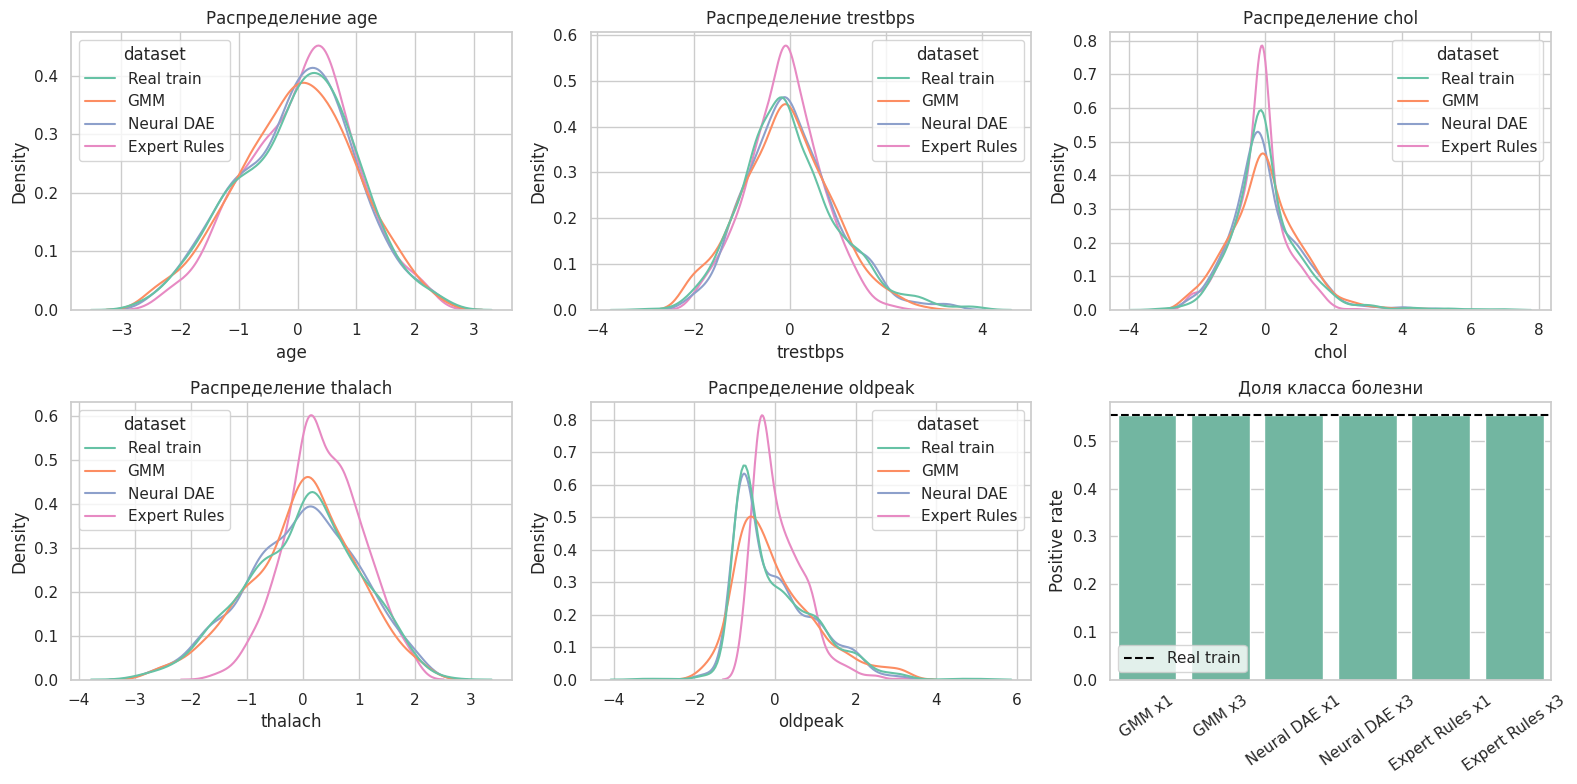

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

plot_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
real_plot = X_train[plot_features].copy()
real_plot["dataset"] = "Real train"

for ax, feature in zip(axes, plot_features):
    combined_parts = [real_plot[[feature, "dataset"]]]
    for generator_id in generator_functions:
        synthetic = synthetic_datasets[(generator_id, 1)]
        part = synthetic[[feature]].copy()
        part["dataset"] = generator_id
        combined_parts.append(part)

    plot_df = pd.concat(combined_parts, ignore_index=True)
    sns.kdeplot(data=plot_df, x=feature, hue="dataset", common_norm=False, ax=ax)
    ax.set_title(f"Распределение {feature}")
    ax.set_xlabel(feature)

class_balance_plot = saved_datasets.copy()
class_balance_plot["Dataset"] = class_balance_plot["Generator"] + " " + class_balance_plot["Size multiplier"]
sns.barplot(data=class_balance_plot, x="Dataset", y="Positive rate", ax=axes[-1])
axes[-1].axhline(y_train.mean(), color="black", linestyle="--", label="Real train")
axes[-1].set_title("Доля класса болезни")
axes[-1].set_xlabel("")
axes[-1].set_ylabel("Positive rate")
axes[-1].tick_params(axis="x", rotation=35)
axes[-1].legend()

plt.tight_layout()
plt.show()

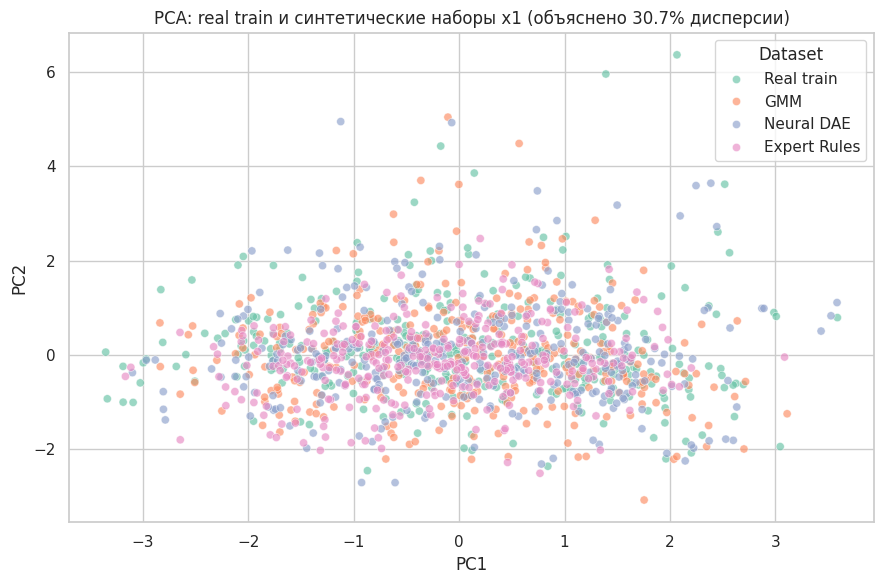

In [12]:
pca_parts = []
pca_sample_size = 350

real_sample = X_train.sample(n=min(pca_sample_size, len(X_train)), random_state=RANDOM_STATE)
real_part = real_sample.copy()
real_part["Dataset"] = "Real train"
pca_parts.append(real_part)

for generator_id in generator_functions:
    synthetic = synthetic_datasets[(generator_id, 1)]
    sample = synthetic[feature_cols].sample(n=min(pca_sample_size, len(synthetic)), random_state=RANDOM_STATE)
    part = sample.copy()
    part["Dataset"] = generator_id
    pca_parts.append(part)

pca_df = pd.concat(pca_parts, ignore_index=True)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(pca_df[feature_cols])

pca_plot = pd.DataFrame(coords, columns=["PC1", "PC2"])
pca_plot["Dataset"] = pca_df["Dataset"].to_numpy()

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_plot, x="PC1", y="PC2", hue="Dataset", alpha=0.65, s=35)
plt.title(
    "PCA: real train и синтетические наборы x1 "
    f"(объяснено {pca.explained_variance_ratio_.sum() * 100:.1f}% дисперсии)"
)
plt.tight_layout()
plt.show()

## 9. TSTR: обучение на синтетике, тест на реальных данных

Для проверки полезности синтетических наборов повторяется логика практики №2:
обучаются логистическая регрессия, случайный лес, градиентный бустинг, обычный
voting-ансамбль и взвешенный voting-ансамбль. Отличие в том, что train-часть
заменяется синтетическими данными, а test-часть остаётся реальной.

In [13]:
def make_base_models():
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
    }


ENSEMBLE_WEIGHTS = {
    "Logistic Regression": 5,
    "Random Forest": 1,
    "Gradient Boosting": 1,
}


def make_voting_estimators(base_models):
    return [
        ("logreg", clone(base_models["Logistic Regression"])),
        ("rf", clone(base_models["Random Forest"])),
        ("gb", clone(base_models["Gradient Boosting"])),
    ]


def make_models():
    base_models = make_base_models()
    weights = [
        ENSEMBLE_WEIGHTS["Logistic Regression"],
        ENSEMBLE_WEIGHTS["Random Forest"],
        ENSEMBLE_WEIGHTS["Gradient Boosting"],
    ]

    return {
        **base_models,
        "Voting Ensemble": VotingClassifier(
            estimators=make_voting_estimators(base_models),
            voting="soft",
            n_jobs=1,
        ),
        "Weighted Voting Ensemble": VotingClassifier(
            estimators=make_voting_estimators(base_models),
            voting="soft",
            weights=weights,
            n_jobs=1,
        ),
    }


def evaluate_tstr(train_frame, source_name, generator_id, multiplier):
    X_source = train_frame[feature_cols].astype(float)
    y_source = train_frame["target"].astype(int)
    rows = []

    for model_name, model in make_models().items():
        fitted = clone(model).fit(X_source, y_source)
        y_pred = fitted.predict(X_test)
        y_score = fitted.predict_proba(X_test)[:, 1]

        rows.append(
            {
                "Train source": source_name,
                "Generator": generator_id,
                "Size multiplier": multiplier,
                "Model": model_name,
                "Train rows": len(train_frame),
                "Real test rows": len(X_test),
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred, zero_division=0),
                "F1": f1_score(y_test, y_pred, zero_division=0),
                "ROC-AUC": roc_auc_score(y_test, y_score),
            }
        )

    return rows


real_train_frame = X_train.copy()
real_train_frame["target"] = y_train.to_numpy()

tstr_rows = []
tstr_rows.extend(evaluate_tstr(real_train_frame, "Real train", "Real", "x1"))

for (generator_id, multiplier), synthetic in synthetic_datasets.items():
    tstr_rows.extend(
        evaluate_tstr(
            synthetic,
            source_name=f"Synthetic {generator_id} x{multiplier}",
            generator_id=generator_id,
            multiplier=f"x{multiplier}",
        )
    )

tstr_results = pd.DataFrame(tstr_rows)
tstr_results["F1 > raw GB baseline"] = tstr_results["F1"] > RAW_GRADIENT_BOOSTING_F1_BASELINE
tstr_results["F1 gap to lab2 best"] = tstr_results["F1"] - BEST_LAB2_PROCESSED_F1

tstr_path = LAB3_DIR / "lab3_tstr_metrics.csv"
tstr_results.sort_values(["F1", "ROC-AUC"], ascending=False).to_csv(tstr_path, index=False)

display(tstr_results.sort_values(["F1", "ROC-AUC"], ascending=False).round(4))
print(f"TSTR-метрики сохранены: {tstr_path.relative_to(PROJECT_ROOT)}")

,Train source,Generator,Size multiplier,Model,Train rows,Real test rows,Accuracy,Precision,Recall,F1,ROC-AUC,F1 > raw GB baseline,F1 gap to lab2 best
4,Real train,Real,x1,Weighted Voting Ensemble,688,230,0.8609,0.8571,0.8976,0.8769,0.9166,True,0.0000
3,Real train,Real,x1,Voting Ensemble,688,230,0.8565,0.8507,0.8976,0.8736,0.9139,True,-0.0034
0,Real train,Real,x1,Logistic Regression,688,230,0.8478,0.8538,0.8740,0.8638,0.9179,True,-0.0131
1,Real train,Real,x1,Random Forest,688,230,0.8435,0.8473,0.8740,0.8605,0.9064,True,-0.0165
24,Synthetic Neural DAE x3,Neural DAE,x3,Weighted Voting Ensemble,2064,230,0.8435,0.8527,0.8661,0.8594,0.9151,True,-0.0175
21,Synthetic Neural DAE x3,Neural DAE,x3,Random Forest,2064,230,0.8435,0.8527,0.8661,0.8594,0.9015,True,-0.0175
16,Synthetic Neural DAE x1,Neural DAE,x1,Random Forest,688,230,0.8391,0.8409,0.8740,0.8571,0.8905,True,-0.0198
23,Synthetic Neural DAE x3,Neural DAE,x3,Voting Ensemble,2064,230,0.8391,0.8516,0.8583,0.8549,0.9128,True,-0.0220
2,Real train,Real,x1,Gradient Boosting,688,230,0.8304,0.8188,0.8898,0.8528,0.9028,True,-0.0241
12,Synthetic GMM x3,GMM,x3,Gradient Boosting,2064,230,0.8304,0.8188,0.8898,0.8528,0.8907,True,-0.0241


TSTR-метрики сохранены: labs/lab3/lab3_tstr_metrics.csv


In [14]:
best_by_train_source = (
    tstr_results
    .sort_values(["F1", "ROC-AUC"], ascending=False)
    .groupby(["Train source", "Generator", "Size multiplier"], as_index=False)
    .head(1)
    .sort_values(["F1", "ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

display(
    best_by_train_source[
        [
            "Train source",
            "Generator",
            "Size multiplier",
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "F1 > raw GB baseline",
            "F1 gap to lab2 best",
        ]
    ].round(4)
)

synthetic_only = tstr_results[tstr_results["Generator"] != "Real"]
best_synthetic = synthetic_only.sort_values(["F1", "ROC-AUC"], ascending=False).iloc[0]

print("Лучший TSTR-результат на синтетике:")
print(
    f"{best_synthetic['Train source']} | {best_synthetic['Model']} | "
    f"F1 = {best_synthetic['F1']:.4f} | "
    f"Accuracy = {best_synthetic['Accuracy']:.4f} | "
    f"ROC-AUC = {best_synthetic['ROC-AUC']:.4f}"
)

print(
    "Порог F1 > 0.7213 пройден:",
    bool(best_synthetic["F1"] > RAW_GRADIENT_BOOSTING_F1_BASELINE),
)

,Train source,Generator,Size multiplier,Model,Accuracy,Precision,Recall,F1,ROC-AUC,F1 > raw GB baseline,F1 gap to lab2 best
0,Real train,Real,x1,Weighted Voting Ensemble,0.8609,0.8571,0.8976,0.8769,0.9166,True,0.0000
1,Synthetic Neural DAE x3,Neural DAE,x3,Weighted Voting Ensemble,0.8435,0.8527,0.8661,0.8594,0.9151,True,-0.0175
2,Synthetic Neural DAE x1,Neural DAE,x1,Random Forest,0.8391,0.8409,0.8740,0.8571,0.8905,True,-0.0198
3,Synthetic GMM x3,GMM,x3,Gradient Boosting,0.8304,0.8188,0.8898,0.8528,0.8907,True,-0.0241
4,Synthetic GMM x1,GMM,x1,Logistic Regression,0.8043,0.8254,0.8189,0.8221,0.8879,True,-0.0548
5,Synthetic Expert Rules x3,Expert Rules,x3,Logistic Regression,0.7913,0.7926,0.8425,0.8168,0.8871,True,-0.0601
6,Synthetic Expert Rules x1,Expert Rules,x1,Random Forest,0.7652,0.7920,0.7795,0.7857,0.8360,True,-0.0912


Лучший TSTR-результат на синтетике:
Synthetic Neural DAE x3 | Weighted Voting Ensemble | F1 = 0.8594 | Accuracy = 0.8435 | ROC-AUC = 0.9151
Порог F1 > 0.7213 пройден: True


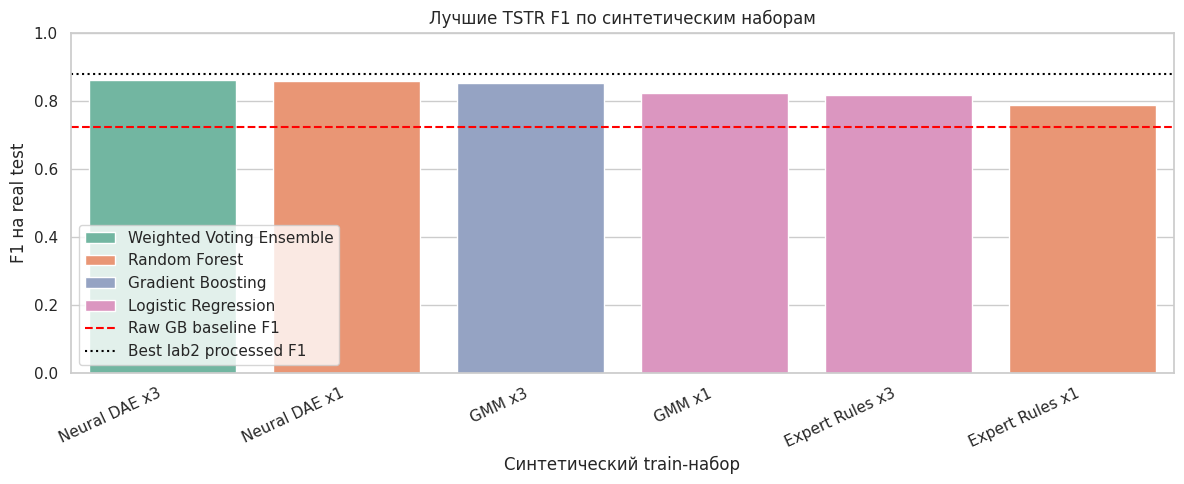

In [15]:
plt.figure(figsize=(12, 5))
plot_data = best_by_train_source[best_by_train_source["Generator"] != "Real"].copy()
plot_data["Dataset"] = plot_data["Generator"] + " " + plot_data["Size multiplier"]

sns.barplot(data=plot_data, x="Dataset", y="F1", hue="Model")
plt.axhline(RAW_GRADIENT_BOOSTING_F1_BASELINE, color="red", linestyle="--", label="Raw GB baseline F1")
plt.axhline(BEST_LAB2_PROCESSED_F1, color="black", linestyle=":", label="Best lab2 processed F1")
plt.title("Лучшие TSTR F1 по синтетическим наборам")
plt.xlabel("Синтетический train-набор")
plt.ylabel("F1 на real test")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Вывод

В работе были построены три типа генераторов табличных данных: классический GMM,
нейронный denoising-autoencoder и экспертный генератор правил. Для каждого
генератора сформированы синтетические train-наборы размера `x1` и `x3` от
реального train.

Статистическая проверка показывает, что после постобработки в синтетических
данных нет некорректных one-hot строк и пропусков. Баланс классов сохранён на
уровне real train, а DCR показывает, что синтетические строки не являются
буквальным копированием всех исходных записей.

Главная объективная проверка - TSTR. Если модель, обученная на синтетике, на
реальном test-наборе показывает F1 выше `0.7213`, то она превышает порог,
заданный результатом Gradient Boosting на сырых данных из практики №2. Лучший
синтетический набор дополнительно сравнивается с ориентиром `0.8769`, который
был получен на processed-данных во второй практической работе.